In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [2]:
carpeta_datos = Path(r"D:\ProyectoAnalisisElectrico\PotencialesClientes")
df = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual_actives_resultados.parquet")
df_dt = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual_actives_processed.parquet")


In [3]:
df_dt.head()

,clave,RUT_CLIENTE,REGION_CLIENTE,macrozona,Zona,Hora,medida_count,medida_min,CLIENTE,CLIENTE_log,...,promedio_ponderado_costo_mwht_bateria,promedio_ponderado_costo_mwht_combustible,ahorro_total_rut_region_usd,ahorro_total_optimo_anual_usd,clave_top_1,clave_top_2,clave_top_3,n_clave_top_1,n_clave_top_2,n_clave_top_3
0,$C$439,79587210-8,Antofagasta,Norte Grande,Norte,0,365,-6463.228844,MINERA ESCONDIDA LIMITADA,MINERA ESCONDIDA LIMITADA,...,6.735354,101.73,1.242869e+07,1.242869e+07,PURI_COLB,PURI_ENEL,FARE_ENEL,209.0,193.0,140.0
1,$C$439,79587210-8,Antofagasta,Norte Grande,Norte,1,365,-6541.272978,MINERA ESCONDIDA LIMITADA,MINERA ESCONDIDA LIMITADA,...,6.735354,101.73,1.242869e+07,1.242869e+07,PURI_COLB,PURI_ENEL,FARE_ENEL,209.0,193.0,140.0
2,$C$439,79587210-8,Antofagasta,Norte Grande,Norte,2,365,-6307.120603,MINERA ESCONDIDA LIMITADA,MINERA ESCONDIDA LIMITADA,...,6.735354,101.73,1.242869e+07,1.242869e+07,PURI_COLB,PURI_ENEL,FARE_ENEL,209.0,193.0,140.0
3,$C$439,79587210-8,Antofagasta,Norte Grande,Norte,3,365,-6495.837207,MINERA ESCONDIDA LIMITADA,MINERA ESCONDIDA LIMITADA,...,6.735354,101.73,1.242869e+07,1.242869e+07,PURI_COLB,PURI_ENEL,FARE_ENEL,209.0,193.0,140.0
4,$C$439,79587210-8,Antofagasta,Norte Grande,Norte,4,365,-6507.573554,MINERA ESCONDIDA LIMITADA,MINERA ESCONDIDA LIMITADA,...,6.735354,101.73,1.242869e+07,1.242869e+07,PURI_COLB,PURI_ENEL,FARE_ENEL,209.0,193.0,140.0


In [4]:
df_dt.columns

Index(['clave', 'RUT_CLIENTE', 'REGION_CLIENTE', 'macrozona', 'Zona', 'Hora',
       'medida_count', 'medida_min', 'CLIENTE', 'CLIENTE_log', 'n_clientes',
       'TIPO', 'NOMBRE_ESTABLECIMIENTO', 'COMBUSTIBLE_PRIMARIO', 'SECTOR',
       'SUBSECTOR', 'RUBRO', 'DEMANDA_CALOR_MWH_sum', 'DEMANDA_CALOR_MWH_mean',
       'DEMANDA_CALOR_MWH_std', 'DEMANDA_CALOR_MWH_max',
       'DEMANDA_CALOR_MWH_min', 'RUT_PROVEEDOR', 'RUT_PROVEEDOR_log',
       'n_rut_proveedores', 'PROVEEDOR', 'PROVEEDOR_log', 'n_proveedores',
       'nombre_barra', 'nombre_barra_log', 'n_nombres_barra', 'tension',
       'tension_log', 'n_tensiones', 'Nombre_Corto', 'Nombre_Corto_log',
       'n_nombres_cortos', 'periodo_last', 'periodos_log', 'meses_operados',
       'medida_mean', 'medida_std', 'CMg[CLP/KWh]_mean', 'CMg[CLP/KWh]_std',
       'CMg[CLP/KWh]_count', 'valorizado_CLP_mean', 'valorizado_CLP_std',
       'valorizado_CLP_count', 'medida_total', 'medida_porcentual',
       'clave_unica', 'id_cluster', 'metodo_cl

findfont: Failed to find font weight 500, now using 400.


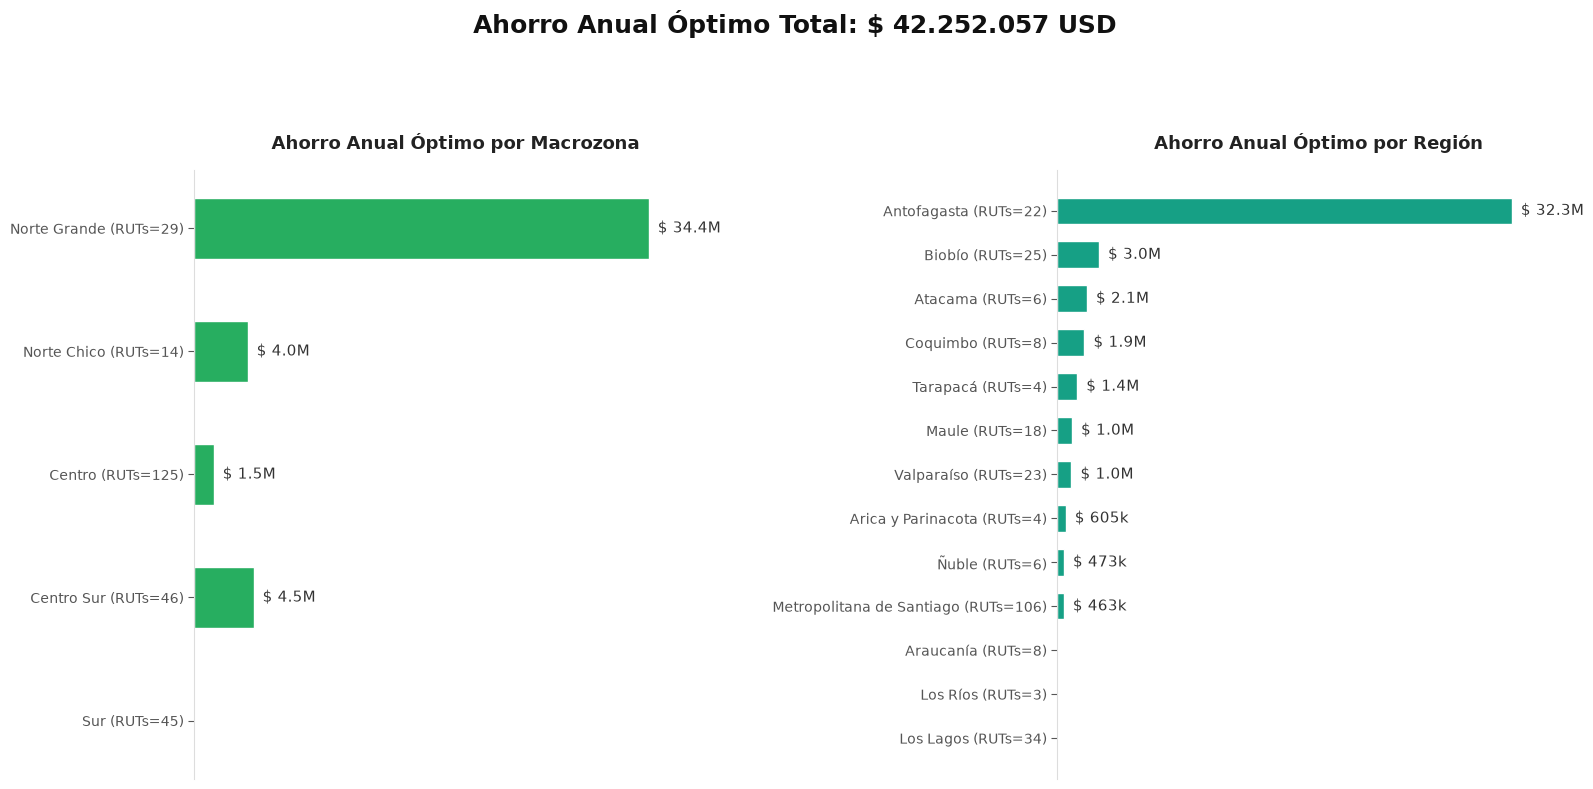

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def graficar_ahorros_totales(df_dt):
    # ==========================================
    # 1. PREPARACIÓN DE DATOS
    # ==========================================
    # Extraemos valores únicos por RUT y Región para no duplicar los ahorros
    columnas_unicas = [
        'RUT_CLIENTE', 
        'REGION_CLIENTE', 
        'macrozona',
        'ahorro_total_optimo_anual_usd'
    ]
    
    # Nos quedamos con una fila por cada RUT y Región y eliminamos vacíos
    df_unico = df_dt.drop_duplicates(subset=['RUT_CLIENTE', 'REGION_CLIENTE'])[columnas_unicas].copy()
    df_unico = df_unico.dropna(subset=['ahorro_total_optimo_anual_usd'])
    
    # ==========================================
    # 2. CÁLCULOS TOTALES
    # ==========================================
    total_ahorro = df_unico['ahorro_total_optimo_anual_usd'].sum()
    
    # Formateo de moneda total (Ej: $ 1.234.567)
    total_str = f"$ {int(total_ahorro):,}".replace(",", ".")
    
    # ==========================================
    # 3. AGRUPACIÓN POR MACROZONA
    # ==========================================
    df_macro = df_unico.groupby('macrozona', observed=False).agg(
        ahorro_optimo=('ahorro_total_optimo_anual_usd', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    # Orden personalizado de macrozonas
    orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
    # Filtrar solo las macrozonas que existen en los datos para evitar errores con pd.Categorical
    macrozonas_presentes = [m for m in orden_macrozonas if m in df_macro['macrozona'].values]
    
    df_macro['macrozona'] = pd.Categorical(df_macro['macrozona'], categories=macrozonas_presentes, ordered=True)
    df_macro = df_macro.sort_values('macrozona').reset_index(drop=True)
    
    # Etiqueta Macrozona
    etiquetas_macro = df_macro['macrozona'].astype(str) + " (RUTs=" + df_macro['total_ruts'].astype(str) + ")"

    # ==========================================
    # 4. AGRUPACIÓN POR REGIÓN
    # ==========================================
    df_region = df_unico.groupby('REGION_CLIENTE').agg(
        ahorro_optimo=('ahorro_total_optimo_anual_usd', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    # Ordenar regiones por el monto de ahorro (de menor a mayor para que las más altas queden arriba en barh)
    df_region = df_region.sort_values('ahorro_optimo', ascending=True).reset_index(drop=True)
    
    # Etiqueta Región
    etiquetas_region = df_region['REGION_CLIENTE'].astype(str) + " (RUTs=" + df_region['total_ruts'].astype(str) + ")"

    # ==========================================
    # 5. CONFIGURACIÓN DEL LIENZO
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    color_macro = '#27AE60' # Verde para representar ahorro/dinero
    color_region = '#16A085' # Verde azulado

    # Función auxiliar para formatear montos en dólares en el gráfico
    def formato_usd(valor):
        if valor >= 1_000_000:
            return f"$ {valor/1_000_000:.1f}M"
        elif valor >= 1_000:
            return f"$ {valor/1_000:.0f}k"
        else:
            return f"$ {int(valor)}"

    # ==========================================
    # 6. GRÁFICO 1: POR MACROZONA
    # ==========================================
    ax1 = axes[0]
    barras_macro = ax1.barh(etiquetas_macro, df_macro['ahorro_optimo'], 
                            height=0.5, color=color_macro, edgecolor='white')
    
    ax1.invert_yaxis() # Para que 'Norte Grande' quede arriba
    
    max_macro = df_macro['ahorro_optimo'].max()
    ax1.set_xlim(0, max_macro * 1.15)
    
    for barra in barras_macro:
        ancho = barra.get_width()
        if ancho > 0:
            texto = formato_usd(ancho)
            ax1.text(ancho + (max_macro * 0.02), barra.get_y() + barra.get_height()/2, 
                     texto, va='center', ha='left', fontsize=11, color='#333333', fontweight='500')

    ax1.set_title("Ahorro Anual Óptimo por Macrozona", color='#222222', fontsize=13, fontweight='bold', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_color('#dddddd')
    ax1.get_xaxis().set_visible(False)
    ax1.tick_params(axis='y', colors='#555555', length=4)

    # ==========================================
    # 7. GRÁFICO 2: POR REGIÓN
    # ==========================================
    ax2 = axes[1]
    barras_region = ax2.barh(etiquetas_region, df_region['ahorro_optimo'], 
                             height=0.6, color=color_region, edgecolor='white')
    
    max_region = df_region['ahorro_optimo'].max()
    ax2.set_xlim(0, max_region * 1.15)
    
    for barra in barras_region:
        ancho = barra.get_width()
        if ancho > 0:
            texto = formato_usd(ancho)
            ax2.text(ancho + (max_region * 0.02), barra.get_y() + barra.get_height()/2, 
                     texto, va='center', ha='left', fontsize=11, color='#333333', fontweight='500')

    ax2.set_title("Ahorro Anual Óptimo por Región", color='#222222', fontsize=13, fontweight='bold', pad=15)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_color('#dddddd')
    ax2.get_xaxis().set_visible(False)
    ax2.tick_params(axis='y', colors='#555555', length=4)

    # ==========================================
    # 8. SUPER TÍTULO (TOTAL) Y AJUSTE FINAL
    # ==========================================
    titulo_principal = f"Ahorro Anual Óptimo Total: {total_str} USD"
    fig.suptitle(titulo_principal, color='#111111', fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.90], w_pad=4)
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
graficar_ahorros_totales(df_dt)

<>:194: SyntaxWarning: invalid escape sequence '\$'
<>:195: SyntaxWarning: invalid escape sequence '\$'
<>:194: SyntaxWarning: invalid escape sequence '\$'
<>:195: SyntaxWarning: invalid escape sequence '\$'
C:\Users\joser\AppData\Local\Temp\ipykernel_11208\659967744.py:194: SyntaxWarning: invalid escape sequence '\$'
  str_optimo_seguro = total_opt_str.replace('$', '\$')
C:\Users\joser\AppData\Local\Temp\ipykernel_11208\659967744.py:195: SyntaxWarning: invalid escape sequence '\$'
  str_promedio_seguro = total_no_opt_str.replace('$', '\$')


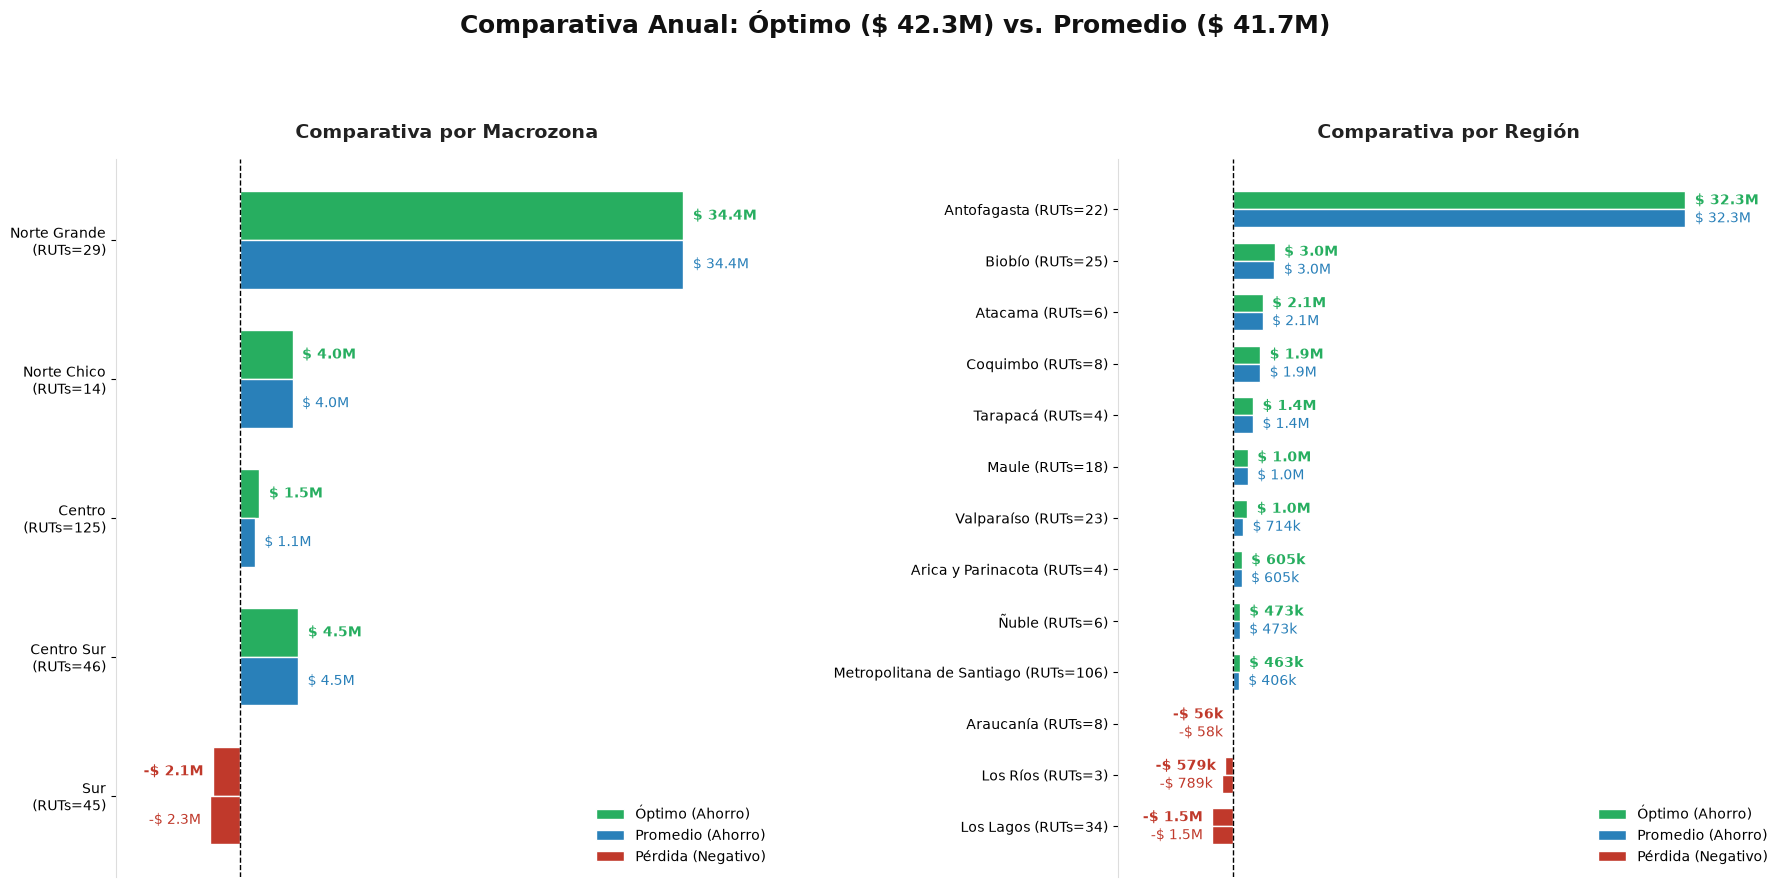

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def graficar_ahorros_comparativos(df_dt):
    # ==========================================
    # 1. PREPARACIÓN DE DATOS
    # ==========================================
    columnas_unicas = [
        'RUT_CLIENTE', 
        'REGION_CLIENTE', 
        'macrozona',
        'ahorro_total_optimo_anual_usd',
        'ahorro_total_rut_region_usd'
    ]

    
    df_unico = df_dt[df_dt["demanda_baterias_factible"] > 0].drop_duplicates(subset=['RUT_CLIENTE', 'REGION_CLIENTE'])[columnas_unicas].copy()
    
    df_unico['ahorro_total_optimo_anual_usd'] = df_unico['ahorro_total_optimo_anual_usd'].fillna(0)
    df_unico['ahorro_total_rut_region_usd'] = df_unico['ahorro_total_rut_region_usd'].fillna(0)
    
    # ==========================================
    # 2. CÁLCULOS TOTALES
    # ==========================================
    total_optimo = df_unico['ahorro_total_optimo_anual_usd'].sum()
    total_no_optimo = df_unico['ahorro_total_rut_region_usd'].sum()
    
    def formato_usd(valor):
        signo = "-" if valor < 0 else ""
        v_abs = abs(valor)
        if v_abs >= 1_000_000:
            return f"{signo}$ {v_abs/1_000_000:.1f}M"
        elif v_abs >= 1_000:
            return f"{signo}$ {v_abs/1_000:.0f}k"
        else:
            return f"{signo}$ {int(v_abs)}"
            
    total_opt_str = formato_usd(total_optimo)
    total_no_opt_str = formato_usd(total_no_optimo)
    
    # ==========================================
    # 3. AGRUPACIÓN POR MACROZONA
    # ==========================================
    df_macro = df_unico.groupby('macrozona', observed=False).agg(
        optimo=('ahorro_total_optimo_anual_usd', 'sum'),
        no_optimo=('ahorro_total_rut_region_usd', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
    macrozonas_presentes = [m for m in orden_macrozonas if m in df_macro['macrozona'].values]
    
    df_macro['macrozona'] = pd.Categorical(df_macro['macrozona'], categories=macrozonas_presentes, ordered=True)
    df_macro = df_macro.sort_values('macrozona').reset_index(drop=True)
    
    etiquetas_macro = df_macro['macrozona'].astype(str) + "\n(RUTs=" + df_macro['total_ruts'].astype(str) + ")"

    # ==========================================
    # 4. AGRUPACIÓN POR REGIÓN
    # ==========================================
    df_region = df_unico.groupby('REGION_CLIENTE').agg(
        optimo=('ahorro_total_optimo_anual_usd', 'sum'),
        no_optimo=('ahorro_total_rut_region_usd', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    df_region = df_region.sort_values('optimo', ascending=True).reset_index(drop=True)
    etiquetas_region = df_region['REGION_CLIENTE'].astype(str) + " (RUTs=" + df_region['total_ruts'].astype(str) + ")"

    # ==========================================
    # 5. CONFIGURACIÓN DEL LIENZO Y COLORES
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    
    color_optimo = '#27AE60'    # Verde
    color_no_optimo = '#2980B9' # Azul
    color_negativo = '#C0392B'  # Rojo (Pérdidas)
    ancho_barra = 0.35          

    legend_elements = [
        Patch(facecolor=color_optimo, edgecolor='white', label='Óptimo (Ahorro)'),
        Patch(facecolor=color_no_optimo, edgecolor='white', label='Promedio (Ahorro)'),
        Patch(facecolor=color_negativo, edgecolor='white', label='Pérdida (Negativo)')
    ]

    # ==========================================
    # 6. GRÁFICO 1: POR MACROZONA
    # ==========================================
    ax1 = axes[0]
    y_macro = np.arange(len(df_macro))
    
    barras_m_optimo = ax1.barh(y_macro - ancho_barra/2, df_macro['optimo'], ancho_barra, 
                               color=[color_optimo if val >= 0 else color_negativo for val in df_macro['optimo']], 
                               edgecolor='white')
    barras_m_no_optimo = ax1.barh(y_macro + ancho_barra/2, df_macro['no_optimo'], ancho_barra, 
                                  color=[color_no_optimo if val >= 0 else color_negativo for val in df_macro['no_optimo']], 
                                  edgecolor='white')
    
    ax1.invert_yaxis() 
    ax1.set_yticks(y_macro)
    ax1.set_yticklabels(etiquetas_macro)
    
    min_m = min(df_macro['optimo'].min(), df_macro['no_optimo'].min(), 0)
    max_m = max(df_macro['optimo'].max(), df_macro['no_optimo'].max(), 0)
    rango_m = max_m - min_m if (max_m - min_m) != 0 else 1
    ax1.set_xlim(min_m - (rango_m * 0.2), max_m + (rango_m * 0.2)) 
    
    if min_m < 0:
        ax1.axvline(0, color='black', linewidth=1, linestyle='--')

    for barra in barras_m_optimo:
        ancho = barra.get_width()
        x_text = ancho + (rango_m * 0.02) if ancho >= 0 else ancho - (rango_m * 0.02)
        ha_text = 'left' if ancho >= 0 else 'right'
        if abs(ancho) > 0.01:
            ax1.text(x_text, barra.get_y() + barra.get_height()/2, 
                     formato_usd(ancho), va='center', ha=ha_text, fontsize=10, 
                     color=color_optimo if ancho >= 0 else color_negativo, fontweight='bold')
            
    for barra in barras_m_no_optimo:
        ancho = barra.get_width()
        x_text = ancho + (rango_m * 0.02) if ancho >= 0 else ancho - (rango_m * 0.02)
        ha_text = 'left' if ancho >= 0 else 'right'
        if abs(ancho) > 0.01:
            ax1.text(x_text, barra.get_y() + barra.get_height()/2, 
                     formato_usd(ancho), va='center', ha=ha_text, fontsize=10, 
                     color=color_no_optimo if ancho >= 0 else color_negativo)

    ax1.set_title("Comparativa por Macrozona", color='#222222', fontsize=14, fontweight='bold', pad=15)
    ax1.legend(handles=legend_elements, loc='lower right', frameon=False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_color('#dddddd')
    ax1.get_xaxis().set_visible(False)

    # ==========================================
    # 7. GRÁFICO 2: POR REGIÓN
    # ==========================================
    ax2 = axes[1]
    y_region = np.arange(len(df_region))
    
    # CORRECCIÓN: Se invierten los signos (+ y -) respecto a ax1 para que el Óptimo (Verde) quede arriba.
    barras_r_optimo = ax2.barh(y_region + ancho_barra/2, df_region['optimo'], ancho_barra, 
                               color=[color_optimo if val >= 0 else color_negativo for val in df_region['optimo']], 
                               edgecolor='white')
    barras_r_no_optimo = ax2.barh(y_region - ancho_barra/2, df_region['no_optimo'], ancho_barra, 
                                  color=[color_no_optimo if val >= 0 else color_negativo for val in df_region['no_optimo']], 
                                  edgecolor='white')
    
    ax2.set_yticks(y_region)
    ax2.set_yticklabels(etiquetas_region)
    
    min_r = min(df_region['optimo'].min(), df_region['no_optimo'].min(), 0)
    max_r = max(df_region['optimo'].max(), df_region['no_optimo'].max(), 0)
    rango_r = max_r - min_r if (max_r - min_r) != 0 else 1
    ax2.set_xlim(min_r - (rango_r * 0.2), max_r + (rango_r * 0.2))
    
    if min_r < 0:
        ax2.axvline(0, color='black', linewidth=1, linestyle='--')
    
    for barra in barras_r_optimo:
        ancho = barra.get_width()
        x_text = ancho + (rango_r * 0.02) if ancho >= 0 else ancho - (rango_r * 0.02)
        ha_text = 'left' if ancho >= 0 else 'right'
        if abs(ancho) > 0.01:
            ax2.text(x_text, barra.get_y() + barra.get_height()/2, 
                     formato_usd(ancho), va='center', ha=ha_text, fontsize=10, 
                     color=color_optimo if ancho >= 0 else color_negativo, fontweight='bold')
            
    for barra in barras_r_no_optimo:
        ancho = barra.get_width()
        x_text = ancho + (rango_r * 0.02) if ancho >= 0 else ancho - (rango_r * 0.02)
        ha_text = 'left' if ancho >= 0 else 'right'
        if abs(ancho) > 0.01:
            ax2.text(x_text, barra.get_y() + barra.get_height()/2, 
                     formato_usd(ancho), va='center', ha=ha_text, fontsize=10, 
                     color=color_no_optimo if ancho >= 0 else color_negativo)

    ax2.set_title("Comparativa por Región", color='#222222', fontsize=14, fontweight='bold', pad=15)
    ax2.legend(handles=legend_elements, loc='lower right', frameon=False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_color('#dddddd')
    ax2.get_xaxis().set_visible(False)

    # ==========================================
    # 8. SUPER TÍTULO (TOTAL)
    # ==========================================
    # CORRECCIÓN: Agregamos replace('$', '\$') para "engañar" al renderizador matemático de Matplotlib
    str_optimo_seguro = total_opt_str.replace('$', '\$')
    str_promedio_seguro = total_no_opt_str.replace('$', '\$')
    
    titulo_principal = f"Comparativa Anual: Óptimo ({str_optimo_seguro}) vs. Promedio ({str_promedio_seguro})"
    fig.suptitle(titulo_principal, color='#111111', fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.92], w_pad=4)
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
graficar_ahorros_comparativos(df_dt)

In [7]:
df_dt.columns

Index(['clave', 'RUT_CLIENTE', 'REGION_CLIENTE', 'macrozona', 'Zona', 'Hora',
       'medida_count', 'medida_min', 'CLIENTE', 'CLIENTE_log', 'n_clientes',
       'TIPO', 'NOMBRE_ESTABLECIMIENTO', 'COMBUSTIBLE_PRIMARIO', 'SECTOR',
       'SUBSECTOR', 'RUBRO', 'DEMANDA_CALOR_MWH_sum', 'DEMANDA_CALOR_MWH_mean',
       'DEMANDA_CALOR_MWH_std', 'DEMANDA_CALOR_MWH_max',
       'DEMANDA_CALOR_MWH_min', 'RUT_PROVEEDOR', 'RUT_PROVEEDOR_log',
       'n_rut_proveedores', 'PROVEEDOR', 'PROVEEDOR_log', 'n_proveedores',
       'nombre_barra', 'nombre_barra_log', 'n_nombres_barra', 'tension',
       'tension_log', 'n_tensiones', 'Nombre_Corto', 'Nombre_Corto_log',
       'n_nombres_cortos', 'periodo_last', 'periodos_log', 'meses_operados',
       'medida_mean', 'medida_std', 'CMg[CLP/KWh]_mean', 'CMg[CLP/KWh]_std',
       'CMg[CLP/KWh]_count', 'valorizado_CLP_mean', 'valorizado_CLP_std',
       'valorizado_CLP_count', 'medida_total', 'medida_porcentual',
       'clave_unica', 'id_cluster', 'metodo_cl

In [9]:
import pandas as pd

# --- 0. LÓGICA PARA CALCULAR EL TOP 3 DE CLAVES ---

# Asegurar que la columna sea numérica
df_dt['n_baterias_cargadas'] = pd.to_numeric(df_dt['n_baterias_cargadas'], errors='coerce')

# Agrupar para obtener el valor máximo de baterías por cada 'clave' única dentro de un RUT+REGION
df_claves = df_dt.groupby(['RUT_CLIENTE', 'REGION_CLIENTE', 'clave'], as_index=False)['n_baterias_cargadas'].max()

# Ordenar de mayor a menor y extraer solo el top 3
df_top = df_claves.sort_values(
    by=['RUT_CLIENTE', 'REGION_CLIENTE', 'n_baterias_cargadas'], 
    ascending=[True, True, False]
)
df_top = df_top.groupby(['RUT_CLIENTE', 'REGION_CLIENTE']).head(3).copy()

# Crear ranking (1, 2, 3)
df_top['ranking'] = df_top.groupby(['RUT_CLIENTE', 'REGION_CLIENTE']).cumcount() + 1

# Pivotear
df_pivot = df_top.pivot(
    index=['RUT_CLIENTE', 'REGION_CLIENTE'], 
    columns='ranking', 
    values=['clave', 'n_baterias_cargadas']
)

# Renombrar columnas generadas por el pivot
nuevas_columnas = []
for col_name, rank in df_pivot.columns:
    if col_name == 'clave':
        nuevas_columnas.append(f'Clave top {rank}')
    else:
        nuevas_columnas.append(f'n_clave_top_{rank}')
        
df_pivot.columns = nuevas_columnas
df_pivot = df_pivot.reset_index()

# Integrar las nuevas columnas al df_dt original
df_dt = df_dt.merge(df_pivot, on=['RUT_CLIENTE', 'REGION_CLIENTE'], how='left')


# --- 1. EXTRACCIÓN Y EXPORTACIÓN ---

# Definir las columnas originales más las nuevas columnas del top 3
columnas_extraer = [
    'CLIENTE', 
    'RUT_CLIENTE', 
    'REGION_CLIENTE', 
    'macrozona',
    'NOMBRE_ESTABLECIMIENTO', 
    'COMBUSTIBLE_PRIMARIO', 
    'SECTOR', 
    'SUBSECTOR', 
    'RUBRO', 
    'DEMANDA_CALOR_MWH_sum', 
    'DEMANDA_CALOR_MWH_mean', 
    'DEMANDA_CALOR_MWH_std', 
    'DEMANDA_CALOR_MWH_max', 
    'DEMANDA_CALOR_MWH_min', 
    'baterias_cargables_por_rut', 
    'baterias_requeridas_por_rut', 
    'demanda_baterias_factible', 
    'promedio_ponderado_costo_mwht_bateria', 
    'promedio_ponderado_costo_mwht_combustible', 
    'ahorro_total_rut_region_usd', 
    'ahorro_total_optimo_anual_usd',
    'mwh_bateria',
    'clave_top_1',
    'n_clave_top_1',
    'clave_top_2',
    'n_clave_top_2',
    'clave_top_3',
    'n_clave_top_3'
]

# 2. Filtrar el DataFrame y quitar duplicados a nivel de Establecimiento
# Esto asegura que cada establecimiento tenga una sola fila en tu Excel
df_exportar = df_dt[columnas_extraer].drop_duplicates(
    subset=['RUT_CLIENTE', 'REGION_CLIENTE', 'NOMBRE_ESTABLECIMIENTO']
).copy()

# 3. Diccionario para renombrar las columnas a nombres comerciales y presentables
nombres_comerciales = {
    'CLIENTE': 'Nombre del Cliente',
    'RUT_CLIENTE': 'RUT',
    'REGION_CLIENTE': 'Región',
    'macrozona': "Macrozona",
    'NOMBRE_ESTABLECIMIENTO': 'Nombre del Establecimiento',
    'COMBUSTIBLE_PRIMARIO': 'Combustible Primario',
    'SECTOR': 'Sector',
    'SUBSECTOR': 'Subsector',
    'RUBRO': 'Rubro',
    'DEMANDA_CALOR_MWH_sum': 'Demanda de Calor Total (MWh)',
    'DEMANDA_CALOR_MWH_mean': 'Demanda de Calor Promedio (MWh)',
    'DEMANDA_CALOR_MWH_std': 'Demanda de Calor Desviación (MWh)',
    'DEMANDA_CALOR_MWH_max': 'Demanda de Calor Máxima (MWh)',
    'DEMANDA_CALOR_MWH_min': 'Demanda de Calor Mínima (MWh)',
    'baterias_cargables_por_rut': 'Baterías Cargables por RUT',
    'baterias_requeridas_por_rut': 'Baterías Requeridas por RUT',
    'demanda_baterias_factible': 'Demanda de Baterías Factible',
    'promedio_ponderado_costo_mwht_bateria': 'Costo Promedio Batería (USD/MWh)',
    'promedio_ponderado_costo_mwht_combustible': 'Costo Promedio Combustible (USD/MWh)',
    'ahorro_total_rut_region_usd': 'Ahorro Anual Promedio (USD)',
    'ahorro_total_optimo_anual_usd': 'Ahorro Anual Óptimo (USD)',
    'mwh_bateria': 'Capacidad de Batería (MWh)',
    'clave_top_1': 'Clave Principal (Top 1)',
    'n_clave_top_1': 'Baterías Cargadas (Top 1)',
    'clave_top_2': 'Clave Secundaria (Top 2)',
    'n_clave_top_2': 'Baterías Cargadas (Top 2)',
    'clave_top_3': 'Clave Terciaria (Top 3)',
    'n_clave_top_3': 'Baterías Cargadas (Top 3)'
}

# 4. Aplicar los nuevos nombres
df_exportar = df_exportar.rename(columns=nombres_comerciales)
# 5. Exportar a Excel
nombre_archivo = 'Reporte_Potencial_Baterias.xlsx'
df_exportar.to_excel(nombre_archivo, index=False)

print(f"¡Exportación exitosa! El archivo se ha guardado como: {nombre_archivo}")

¡Exportación exitosa! El archivo se ha guardado como: Reporte_Potencial_Baterias.xlsx
